In [19]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

In [7]:
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    Image, PageBreak
)

In [13]:
DATA_PATH="C:\\Users\\alzamfir\\Downloads\\HW ML1\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [14]:
print(df.info())
print("\nMissing values:\n")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth              70692 no

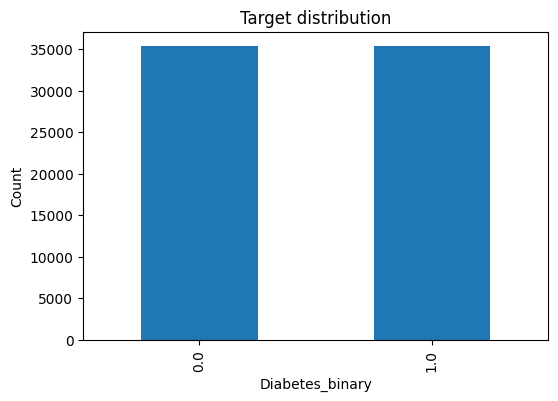

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(6,4))
df['Diabetes_binary'].value_counts().plot(kind='bar')
plt.title("Target distribution")
plt.xlabel("Diabetes_binary")
plt.ylabel("Count")
plt.show()

print(df['Diabetes_binary'].value_counts())

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


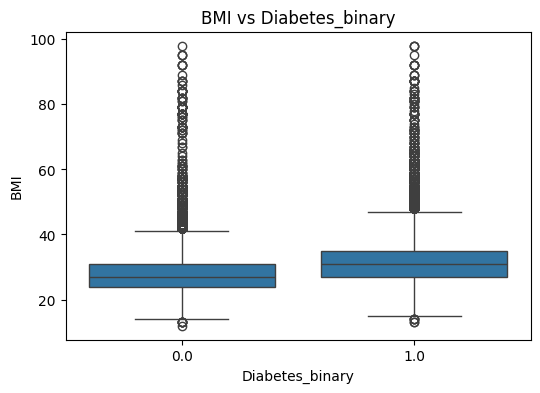

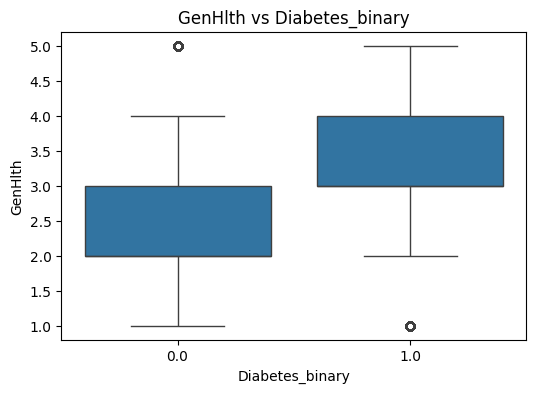

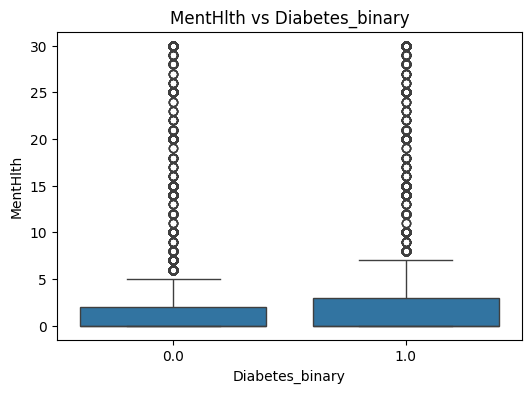

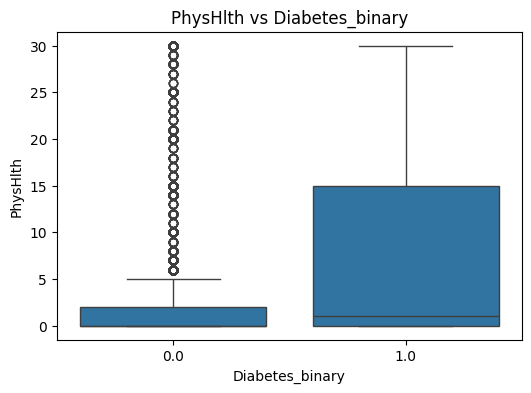

In [21]:
features_to_plot = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth']

for col in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df['Diabetes_binary'], y=df[col])
    plt.title(f"{col} vs Diabetes_binary")
    plt.show()

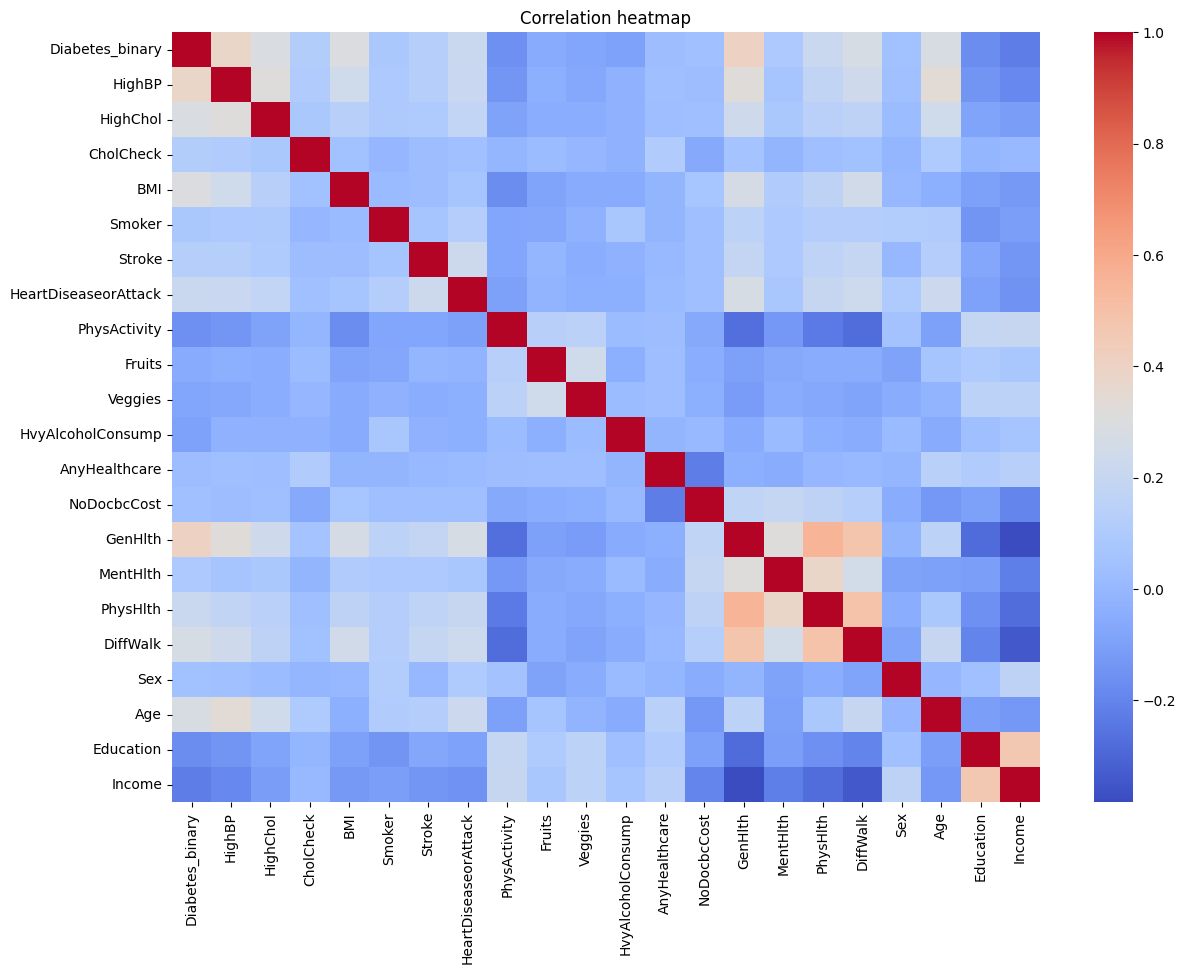

In [22]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation heatmap")
plt.show()

In [23]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70692, 21)
y shape: (70692,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (56553, 21)
X_test : (14139, 21)
y_train: (56553,)
y_test : (14139,)


In [25]:
X_train_v1 = X_train.copy()

norm = Normalizer().fit(X_train_v1)
norm_X_train = norm.transform(X_train_v1)

print("Original variances:")
print(X_train_v1.var(axis=0).head())

print("\nVariances after normalization:")
print(pd.DataFrame(norm_X_train, columns=X_train.columns).var(axis=0).head())

Original variances:
HighBP        0.246045
HighChol      0.249353
CholCheck     0.023874
BMI          50.654943
Smoker        0.249401
dtype: float64

Variances after normalization:
HighBP       0.000214
HighChol     0.000223
CholCheck    0.000061
BMI          0.011501
Smoker       0.000232
dtype: float64


In [26]:
selector = VarianceThreshold(threshold=1e-4)
selected_features_var = selector.fit_transform(norm_X_train)

selected_columns_var = X_train.columns[selector.get_support()]
print("Selected columns with VarianceThreshold:")
print(selected_columns_var.tolist())
print("Number of selected features:", len(selected_columns_var))

Selected columns with VarianceThreshold:
['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Number of selected features: 15


In [27]:
dt = DecisionTreeClassifier(random_state=500)

dt.fit(X_train, y_train)
preds_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, preds_dt)
dt_f1 = f1_score(y_test, preds_dt)

print("Decision Tree with all features")
print("Accuracy:", round(dt_acc, 4))
print("F1-score:", round(dt_f1, 4))

Decision Tree with all features
Accuracy: 0.6506
F1-score: 0.648


In [28]:
X_train_var = X_train[selected_columns_var]
X_test_var = X_test[selected_columns_var]

dt.fit(X_train_var, y_train)
preds_dt_var = dt.predict(X_test_var)

dt_var_acc = accuracy_score(y_test, preds_dt_var)
dt_var_f1 = f1_score(y_test, preds_dt_var)

print("Decision Tree with VarianceThreshold features")
print("Accuracy:", round(dt_var_acc, 4))
print("F1-score:", round(dt_var_f1, 4))

Decision Tree with VarianceThreshold features
Accuracy: 0.659
F1-score: 0.6552


In [29]:
X_train_v2 = X_train.copy()
X_test_v2 = X_test.copy()

# chi2 needs non-negative values, and our dataset is already non-negative
f1_score_list = []

for k in range(1, X_train.shape[1] + 1):
    selector = SelectKBest(score_func=chi2, k=k)
    selector.fit(X_train_v2, y_train)

    sel_X_train_v2 = selector.transform(X_train_v2)
    sel_X_test_v2 = selector.transform(X_test_v2)

    dt.fit(sel_X_train_v2, y_train)
    kbest_preds = dt.predict(sel_X_test_v2)

    f1_score_kbest = round(f1_score(y_test, kbest_preds), 4)
    f1_score_list.append(f1_score_kbest)

print(f1_score_list)

[0.5207, 0.6555, 0.6253, 0.6674, 0.6758, 0.6806, 0.669, 0.6523, 0.6513, 0.6533, 0.6516, 0.655, 0.6494, 0.6492, 0.651, 0.6445, 0.65, 0.6485, 0.6477, 0.6508, 0.648]


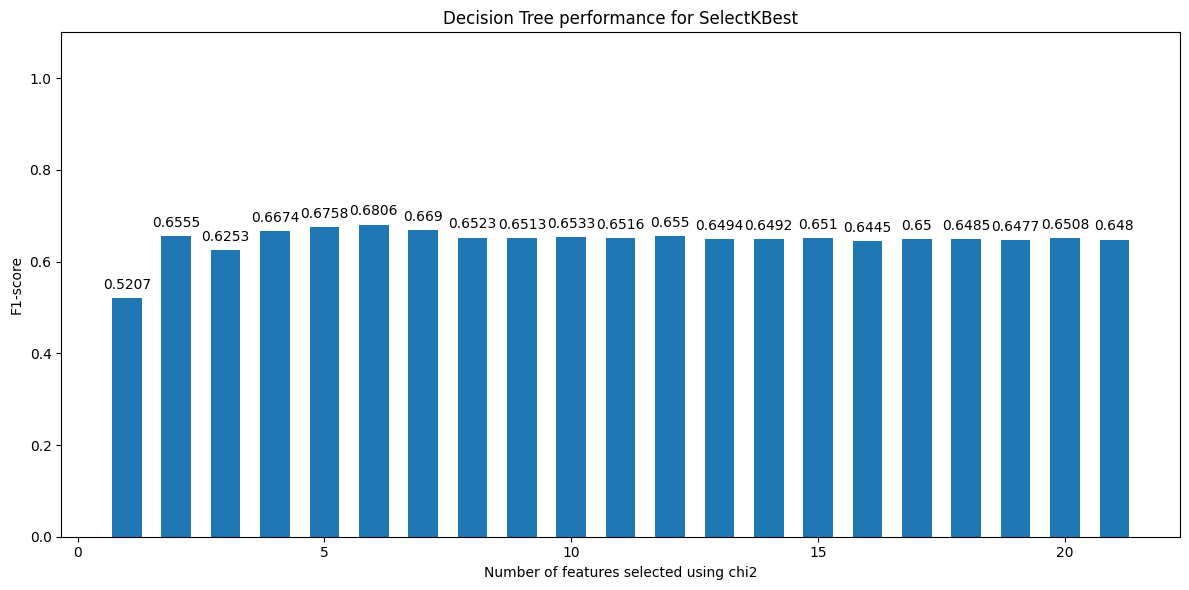

In [30]:
fig, ax = plt.subplots(figsize=(12,6))
x_vals = list(range(1, X_train.shape[1] + 1))
y_vals = f1_score_list

ax.bar(x_vals, y_vals, width=0.6)
ax.set_xlabel("Number of features selected using chi2")
ax.set_ylabel("F1-score")
ax.set_title("Decision Tree performance for SelectKBest")
ax.set_ylim(0, 1.1)

for index, value in enumerate(y_vals):
    plt.text(x=x_vals[index], y=value + 0.02, s=str(value), ha='center')

plt.tight_layout()
plt.show()

In [31]:
best_k = np.argmax(f1_score_list) + 1
print("Best k:", best_k)
print("Best F1-score:", max(f1_score_list))

Best k: 6
Best F1-score: 0.6806


In [32]:
selector_best = SelectKBest(score_func=chi2, k=best_k)
selector_best.fit(X_train, y_train)

selected_columns_kbest = X_train.columns[selector_best.get_support()]
print("Selected columns with SelectKBest:")
print(selected_columns_kbest.tolist())

Selected columns with SelectKBest:
['HighBP', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']


In [33]:
X_train_kbest = selector_best.transform(X_train)
X_test_kbest = selector_best.transform(X_test)

dt.fit(X_train_kbest, y_train)
preds_dt_kbest = dt.predict(X_test_kbest)

dt_kbest_acc = accuracy_score(y_test, preds_dt_kbest)
dt_kbest_f1 = f1_score(y_test, preds_dt_kbest)

print("Decision Tree with SelectKBest features")
print("Accuracy:", round(dt_kbest_acc, 4))
print("F1-score:", round(dt_kbest_f1, 4))

Decision Tree with SelectKBest features
Accuracy: 0.6852
F1-score: 0.6806


In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

preds_lr = log_reg.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, preds_lr)
lr_f1 = f1_score(y_test, preds_lr)

print("Logistic Regression")
print("Accuracy:", round(lr_acc, 4))
print("F1-score:", round(lr_f1, 4))

Logistic Regression
Accuracy: 0.7458
F1-score: 0.7503


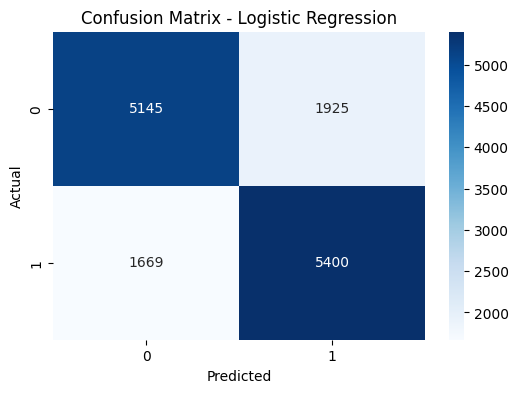

In [35]:
cm = confusion_matrix(y_test, preds_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, preds_lr))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



No Skill ROC AUC: 0.5
Logistic Regression ROC AUC: 0.8232


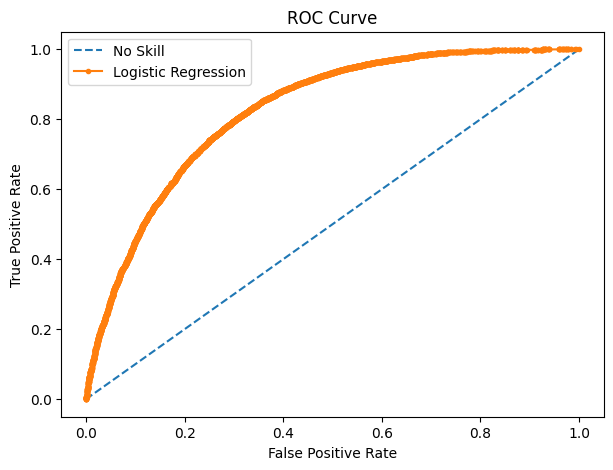

In [37]:
lr_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

ns_probs = [0 for _ in range(len(y_test))]

ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

print("No Skill ROC AUC:", round(ns_auc, 4))
print("Logistic Regression ROC AUC:", round(lr_auc, 4))

ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

plt.figure(figsize=(7,5))
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic Regression')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [38]:
dt.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
13,GenHlth,0.169752
3,BMI,0.132601
18,Age,0.104736
20,Income,0.084875
0,HighBP,0.080336
15,PhysHlth,0.068732
19,Education,0.063565
14,MentHlth,0.053938
8,Fruits,0.032000
4,Smoker,0.030343


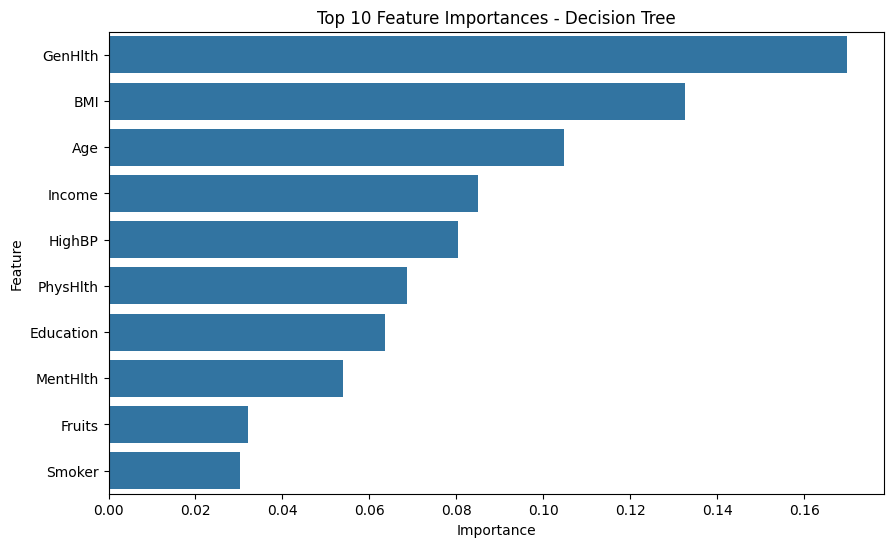

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances - Decision Tree")
plt.show()

In [40]:
results = pd.DataFrame({
    'Model': [
        'Decision Tree - All Features',
        'Decision Tree - VarianceThreshold',
        'Decision Tree - SelectKBest',
        'Logistic Regression'
    ],
    'Accuracy': [
        dt_acc,
        dt_var_acc,
        dt_kbest_acc,
        lr_acc
    ],
    'F1-score': [
        dt_f1,
        dt_var_f1,
        dt_kbest_f1,
        lr_f1
    ]
})

results

,Model,Accuracy,F1-score
0,Decision Tree - All Features,0.650612,0.648048
1,Decision Tree - VarianceThreshold,0.658957,0.655227
2,Decision Tree - SelectKBest,0.685197,0.680588
3,Logistic Regression,0.745809,0.750313


In [41]:
best_model_row = results.sort_values(by='F1-score', ascending=False).iloc[0]
print("Best model based on F1-score:")
print(best_model_row)

Best model based on F1-score:
Model       Logistic Regression
Accuracy               0.745809
F1-score               0.750313
Name: 3, dtype: object
